# POC — Bag-of-Cells Logreg (Checkpoint 0)

Manual validation of the modeling spine on **Schürch CRC / `clr_dii`**: instantiate a
**dataset + task + mean-pool bag-of-cells logreg** and train it for a single train/val/test
split. This notebook grows stage by stage and stays runnable at every step:

- **S3** — DataModule (no edges): one batch — shapes, label mapping, patient ids. *(this stage)*
- **S4** — single `StratifiedGroupKFold`: patient-disjoint train/val/test, zero leakage.
- **S5** — `SpModel` (identity · none · mean · logreg): batch → logits `[n_samples, n_classes]`.
- **S6** — `LitClassifier` + patient-level metrics: `trainer.fit` → loss ↓, val AUROC/AUPRC/F1/bacc.

Everything is driven by the Hydra config in `conf/` — the same config `python -m sp_ml.run` uses.

In [116]:
import collections
import pathlib

import sp_ml
import sp_ml.configs as C
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate

# Locate repo paths off the installed package → cwd-independent (works from any notebook dir).
REPO = pathlib.Path(sp_ml.__file__).resolve().parent.parent     # .../sp-ml
CONF = str(REPO / "conf")
DATA = str(REPO.parent / "data")                                # .../spatialproteomics/data

C.register_configs()
with initialize_config_dir(version_base=None, config_dir=CONF):
    cfg = compose(config_name="config", overrides=[f"paths.data={DATA}"])

print("dataset:", cfg.data.name, "| task:", cfg.task.name, cfg.task.kind, list(cfg.task.classes))
print("h5ad:", cfg.data.h5ad_path)

dataset: schurch | task: clr_dii binary ['CLR', 'DII']
h5ad: /cv/scratch/u/ratzana/spatialproteomics/data/schurch2020/crc.h5ad


## S3 — DataModule (bag-of-cells, no edges)

One PyG `Data` per `Region` (the imaged TMA sample). `y` is the patient-level CLR/DII label
mapped to a class index; `patient` is carried on each graph for patient-grouped CV (S4) and
patient-level scoring (S6). `num_workers=0` keeps it notebook-safe.

In [117]:
dm = instantiate(cfg.data, task=cfg.task, num_workers=0)
dm.setup()

print("n sample-graphs:", len(dm.graphs), "| dropped:", dm.n_dropped)
print("num_markers:", dm.num_markers, "| num_classes:", dm.num_classes)
print("n unique patients:", len({g.patient for g in dm.graphs}))
yc = collections.Counter(int(g.y) for g in dm.graphs)
print("graph-label counts (class_idx -> n_regions):", dict(yc), "| classes:", list(cfg.task.classes))

n sample-graphs: 70 | dropped: 0
num_markers: 58 | num_classes: 2
n unique patients: 35
graph-label counts (class_idx -> n_regions): {0: 34, 1: 36} | classes: ['CLR', 'DII']


### Inspect one batch
Expect: `x = [total_cells, num_markers]` float32, `y = [batch_size]`, a `batch` vector mapping
each cell to its graph, and `patient`/`sample_id` as length-`batch_size` string lists.

In [118]:
batch = next(iter(dm.all_dataloader()))
print("batch:", batch)
print("x:", tuple(batch.x.shape), batch.x.dtype, "| y:", batch.y.tolist())
print("n_graphs:", batch.num_graphs, "| per-graph cells:", batch.batch.bincount().tolist())
print("patient:", batch.patient)
print("sample_id:", batch.sample_id)
print("edge_index present:", getattr(batch, "edge_index", None) is not None, "(bag-of-cells → none)")
assert batch.x.shape[0] == int(batch.batch.bincount().sum())
assert batch.x.shape[1] == dm.num_markers
assert len(batch.patient) == batch.num_graphs == batch.y.numel()
print("\nS3 OK — shapes, label mapping, and patient ids all check out.")

batch: DataBatch(x=[29842, 58], y=[8], sample_id=[8], patient=[8], batch=[29842], ptr=[9])
x: (29842, 58) torch.float32 | y: [0, 0, 1, 1, 1, 1, 1, 1]
n_graphs: 8 | per-graph cells: [1524, 4092, 2562, 3454, 4261, 3605, 5556, 4788]
patient: ['1', '1', '2', '2', '3', '3', '4', '4']
sample_id: ['reg001', 'reg002', 'reg003', 'reg004', 'reg005', 'reg006', 'reg007', 'reg008']
edge_index present: False (bag-of-cells → none)

S3 OK — shapes, label mapping, and patient ids all check out.


## S4 — single train/val/test split (patient-grouped, label-stratified)

One outer fold of `StratifiedGroupKFold` as a **3:1:1** split: grouped on `patient` (a
patient's 2 regions never split across folds → no leakage) and stratified on the CLR/DII
label (each fold mirrors the cohort class ratio). The split is deterministic in
`(seed, repeat, fold)`; Checkpoint 0 uses `fold=0, repeat=0`.

In [119]:
import collections

from sp_ml.data.crossval import HoldoutSplit

dm.split = HoldoutSplit(n_folds=cfg.cv.n_folds, fold=cfg.cv.fold,
                        repeat=cfg.cv.repeat, seed=cfg.cv.seed)
dm.setup()   # graphs already built in S3; this just applies the split

g = dm.graphs
patients = lambda idx: {g[i].patient for i in idx}
labels = lambda idx: collections.Counter(int(g[i].y) for i in idx)
classes = list(cfg.task.classes)

print("regions : train=%d val=%d test=%d (total %d)" % (len(dm.tr), len(dm.va), len(dm.te), len(g)))
ptr, pva, pte = patients(dm.tr), patients(dm.va), patients(dm.te)
print("patients: train=%d val=%d test=%d" % (len(ptr), len(pva), len(pte)))

for name, idx in [("train", dm.tr), ("val", dm.va), ("test", dm.te)]:
    c = labels(idx); tot = sum(c.values())
    print("  %-5s:" % name, {classes[k]: c[k] for k in sorted(c)}, "| DII frac=%.2f" % (c[1] / tot))

regions : train=42 val=14 test=14 (total 70)
patients: train=21 val=7 test=7
  train: {'CLR': 20, 'DII': 22} | DII frac=0.52
  val  : {'CLR': 8, 'DII': 6} | DII frac=0.43
  test : {'CLR': 6, 'DII': 8} | DII frac=0.57


### Zero-leakage assertions (the gate)

In [120]:
assert ptr & pva == set() and ptr & pte == set() and pva & pte == set(), "PATIENT LEAKAGE"
assert ptr | pva | pte == {gg.patient for gg in g}, "a patient is missing from the split"
assert len(dm.tr) + len(dm.va) + len(dm.te) == len(g), "region count mismatch"
for name, idx in [("train", dm.tr), ("val", dm.va), ("test", dm.te)]:
    assert all(c == 2 for c in collections.Counter(g[i].patient for i in idx).values()), \
        f"{name}: a patient's regions were split"
print("S4 OK — train/val/test patient-disjoint (zero leakage), grouping + stratification intact.")

S4 OK — train/val/test patient-disjoint (zero leakage), grouping + stratification intact.


## S5 — the model (`encoder → graph → pool → readout`)

The POC `SpModel`: `Identity` encoder · `NoGraph` · `MeanPool` · `LogReg`. Each component
follows the uniform `in_dim → out_dim` contract, so shapes thread eagerly at build time and
the readout sees `pool.out_dim` (here 58, since identity/none/mean all preserve width). One
batch → logits `[n_samples, n_classes]`.

In [121]:
import torch

from sp_ml.models import SpModel

encoder = instantiate(cfg.model.encoder, in_dim=dm.num_markers)
graph = instantiate(cfg.model.graph, in_dim=encoder.out_dim)
pool = instantiate(cfg.model.pool, in_dim=graph.out_dim)
readout = instantiate(cfg.model.readout, in_dim=pool.out_dim, num_classes=dm.num_classes)
model = SpModel(encoder, graph, pool, readout)

print("shape chain: %d -> %d -> %d -> %d -> classes=%d" %
      (dm.num_markers, encoder.out_dim, graph.out_dim, pool.out_dim, readout.out_dim))
print("trainable params:", sum(p.numel() for p in model.parameters()))
print(model)

b = next(iter(dm.train_dataloader()))
model.eval()
with torch.no_grad():
    logits = model(b)
print("\nbatch graphs:", b.num_graphs, "| logits:", tuple(logits.shape))
assert logits.shape == (b.num_graphs, dm.num_classes)
assert torch.isfinite(logits).all()
print("S5 OK — forward → logits [n_samples, n_classes].")

shape chain: 58 -> 58 -> 58 -> 58 -> classes=2
trainable params: 118
SpModel(
  (encoder): Identity()
  (graph): NoGraph()
  (pool): MeanPool()
  (readout): LogReg(
    (linear): Linear(in_features=58, out_features=2, bias=True)
  )
)

batch graphs: 8 | logits: (8, 2)
S5 OK — forward → logits [n_samples, n_classes].


## Benchmark context — simple/standard baselines

This is the **Schürch CRC, CLR vs DII** task (binary, patient-level). Reported baselines on this
exact dataset frame what "good" looks like (from the NotebookLM notes: SORBET benchmarking, Ali
et al.):

| Model | Type | AUROC |
|---|---|---|
| SORBET | spatial GNN | **0.98** (SOTA) |
| Augur-SC | non-spatial single-cell | 0.91 |
| CITRUS-SC | non-spatial single-cell | 0.86 |
| SPACE-GM | spatial GNN | 0.81 |
| CytoCommunity | spatial graph | 0.78 |

**Our model is a non-spatial bag-of-cells logreg** (mean-pooled `exprs_norm`, no edges) — its
closest analogues are Augur-SC / CITRUS-SC (**~0.86–0.91 AUROC**). Ali et al. find spatial edges
add only ~ΔAUPR 0.052 here, so cell expression alone is highly predictive: a correctly-fit floor
should clear **AUROC 0.80** and approach the non-spatial 0.86–0.91 regime. Watch **AUROC + AUPR**
(threshold-free) and **balanced accuracy** (honest under imbalance — currently the metric to move).

## Train the floor model + report

Train the bag-of-cells logreg on the single fold **to convergence** (more epochs than the original
Checkpoint-0 smoke), tracking the **loss curve + metrics to W&B**. Metrics are scored at the
**patient level** (`aggregate_by_patient`). Then visualize loss curves and a patient-level
evaluation panel (confusion matrix, ROC, PR, per-class precision/recall).

In [122]:
import os
import warnings

import lightning as L
from lightning.pytorch.loggers import WandbLogger

from sp_ml.train import LitClassifier, class_weights

warnings.filterwarnings("ignore")
L.seed_everything(cfg.seed, verbose=False)

EPOCHS = 300            # ↑ from the 40-epoch Checkpoint-0 smoke — let the logreg actually converge

# W&B: loss curve + metrics track live. Online by default (account default entity); set env
# WANDB_MODE=offline to log locally (sync later), or WANDB_MODE=disabled to skip W&B entirely.
wb_mode = os.environ.get("WANDB_MODE", "online")
wandb_logger = (
    False if wb_mode == "disabled"
    else WandbLogger(project=cfg.wandb.project, offline=(wb_mode != "online"),
                     group="schurch-clr_dii-bagcells", name=f"poc-logreg-{EPOCHS}ep",
                     save_dir="outputs")
)

w = class_weights(dm.train_labels(), dm.num_classes) if cfg.train.class_weighted else None
print("class weights (train-fold inverse freq):", None if w is None else [round(float(x), 3) for x in w])

loss = instantiate(cfg.train.get("loss"), weight=w)
optimizer = instantiate(cfg.train.optimizer)   # functools.partial (_partial_: true)
lit = LitClassifier(model=model, optimizer=optimizer, loss=loss, num_classes=dm.num_classes)


class LossHistory(L.Callback):
    """Capture epoch-level train & val loss during fit for a local loss curve."""

    def __init__(self):
        self.train, self.val = [], []

    def on_train_epoch_end(self, trainer, _):
        v = trainer.callback_metrics.get("train/loss")
        if v is not None:
            self.train.append(float(v))

    def on_validation_epoch_end(self, trainer, _):
        if trainer.state.fn != "fit":     # ignore the post-fit validate/test passes
            return
        v = trainer.callback_metrics.get("val/loss")
        if v is not None:
            self.val.append(float(v))


hist = LossHistory()
trainer = instantiate(cfg.train.trainer, max_epochs=EPOCHS, logger=wandb_logger,
                      enable_checkpointing=False, enable_progress_bar=False,
                      enable_model_summary=False, num_sanity_val_steps=0, callbacks=[hist])
trainer.fit(lit, dm)
print(f"trained {EPOCHS} epochs | W&B: {wb_mode}")

class weights (train-fold inverse freq): [1.05, 0.955]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.


trained 300 epochs | W&B: online


### Loss curves

train loss: first=0.6951  last=0.3537  min=0.3527


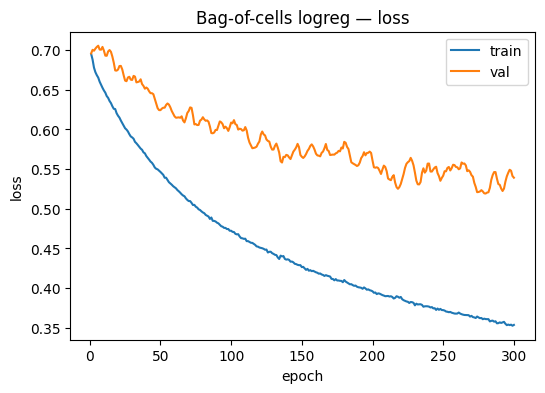

In [123]:
import matplotlib.pyplot as plt

print("train loss: first=%.4f  last=%.4f  min=%.4f" % (hist.train[0], hist.train[-1], min(hist.train)))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(hist.train) + 1), hist.train, label="train")
if hist.val:
    ax.plot(range(1, len(hist.val) + 1), hist.val, label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
ax.set_title("Bag-of-cells logreg — loss")
plt.show()

### Patient-level metrics + benchmark comparison

In [124]:
valm = trainer.validate(lit, dm, verbose=False)[0]
testm = trainer.test(lit, dm, verbose=False)[0]
keys = ("auroc", "auprc", "f1", "bacc")
for d, split in [(valm, "val"), (testm, "test")]:
    print("%-5s (patient-level):" % split,
          "  ".join("%s=%.3f" % (k, d[f"{split}/{k}"]) for k in keys))
print("\nbaseline context — non-spatial ≈ 0.86–0.91 AUROC (Augur-SC/CITRUS-SC); SOTA spatial ≈ 0.98 (SORBET)")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


val   (patient-level): auroc=1.000  auprc=1.000  f1=0.708  bacc=0.750
test  (patient-level): auroc=0.833  auprc=0.877  f1=0.571  bacc=0.583

baseline context — non-spatial ≈ 0.86–0.91 AUROC (Augur-SC/CITRUS-SC); SOTA spatial ≈ 0.98 (SORBET)


### Evaluation panel (patient-level, test fold)

              precision    recall  f1-score   support

         CLR       0.50      0.67      0.57         3
         DII       0.67      0.50      0.57         4

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



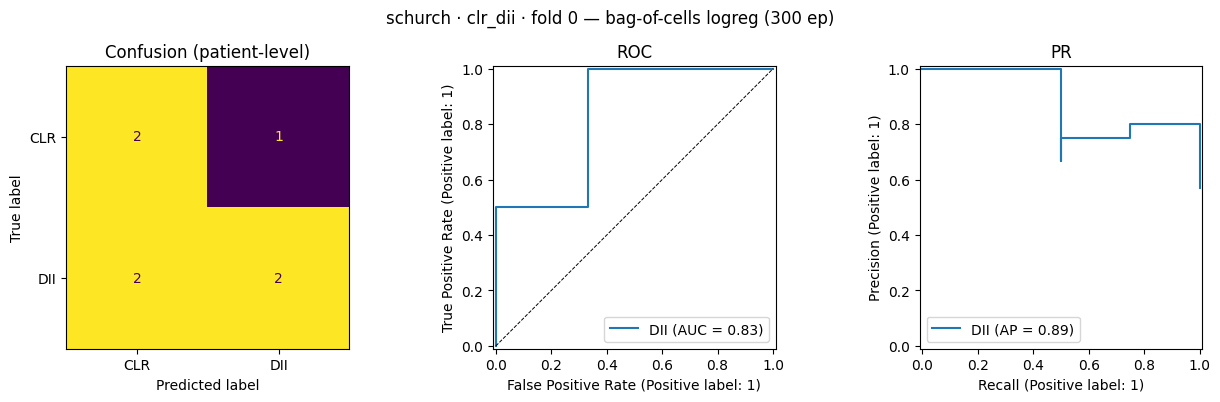

In [125]:
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, classification_report,
)

from sp_ml.train import aggregate_by_patient

dev = next(lit.model.parameters()).device
lit.eval()
buf = []
with torch.no_grad():
    for bb in dm.test_dataloader():
        bb = bb.to(dev)
        buf.append((lit.model(bb).softmax(-1).cpu(), bb.y.cpu(), list(bb.patient)))
probs, yy = aggregate_by_patient(buf)
probs, yy = probs.numpy(), yy.numpy().astype(int)
pred, pos = probs.argmax(1), probs[:, 1]      # pos = P(DII)
classes = list(cfg.task.classes)

print(classification_report(yy, pred, target_names=classes, zero_division=0))
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ConfusionMatrixDisplay.from_predictions(yy, pred, display_labels=classes, ax=ax[0], colorbar=False)
ax[0].set_title("Confusion (patient-level)")
RocCurveDisplay.from_predictions(yy, pos, ax=ax[1], name=classes[1])
ax[1].plot([0, 1], [0, 1], "k--", lw=0.7); ax[1].set_title("ROC")
PrecisionRecallDisplay.from_predictions(yy, pos, ax=ax[2], name=classes[1])
ax[2].set_title("PR")
fig.suptitle(f"{cfg.data.name} · {cfg.task.name} · fold {cfg.cv.fold} — bag-of-cells logreg ({EPOCHS} ep)")
fig.tight_layout()
plt.show()

In [126]:
import wandb

if wandb_logger:
    wandb.finish()

epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇███▁▂▂▂▂▃
test/auprc,▁
test/auroc,▁
test/bacc,▁
test/f1,▁
test/loss,▁
train/loss,▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁█▇▇▆▅▄▃▃▃▃
trainer/global_step,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇█▁▁▂▂▂▃▃
val/auprc,▅▅████████████████████████████████▁▁▁▁██
val/auroc,▅█████████████████████████████▁▁▁▁▁▁▅███
+3,...
